In [25]:
import os
import sys
import random
import Levenshtein
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from torchinfo import summary
import torch
import pandas as pd
from pathlib import Path
import torch
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Setup paths for custom modules
sys.path.append(os.path.abspath(os.path.join("../..")))
from src.datasets.huggingfacefilelistdataset import HuggingFaceFileListDataset
from src.models.crnn.crnn_v1 import Captcha_CRNN_V1

In [26]:
captcha_transformation = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((40, 150)),
    transforms.ToTensor()
])

In [27]:
test_dataset = HuggingFaceFileListDataset(
    file_list="../crnn/test_file_list_crnn_v6.txt",
    transform=captcha_transformation
)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Captcha_CRNN_V1(num_chars=len(test_dataset.vocab) + 1)
model_path = Captcha_CRNN_V1.SAVE_DIR / "v6.pth"

state_dict = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print(f"Model successfully loaded from {model_path}")

Model successfully loaded from /nfs/home/tpz8688/Captcha-Recognition/weights/crnn/v6.pth


In [29]:
def plot_char_confusion_matrix(results_df, dataset, hide_diagonal=False):
    char_actual = []
    char_pred = []
    
    vocab = sorted(list(dataset.vocab))
    labels = vocab + ['Ø'] 
    
    for _, row in results_df.iterrows():
        # FIX: Force conversion to string and replace NaN with empty string
        actual = str(row['actual']) if pd.notna(row['actual']) else ""
        pred = str(row['prediction']) if pd.notna(row['prediction']) else ""
        
        # Now max(len(actual), len(pred)) will work even if one is empty
        max_len = max(len(actual), len(pred))
        actual_padded = actual.ljust(max_len, 'Ø') 
        pred_padded = pred.ljust(max_len, 'Ø')
        
        for a, p in zip(actual_padded, pred_padded):
            char_actual.append(a)
            char_pred.append(p)

    # Generate the raw confusion matrix
    cm = confusion_matrix(char_actual, char_pred, labels=labels)
    
    # If requested, zero out the diagonal to highlight errors
    if hide_diagonal:
        np.fill_diagonal(cm, 0)
        title = 'Character-Level Confusion Matrix (Errors Only)'
        cmap = 'OrRd' # Switching to red-scale makes errors pop more
    else:
        title = 'Character-Level Confusion Matrix'
        cmap = 'Blues'
    
    # Plotting
    plt.figure(figsize=(22, 18))
    sns.heatmap(cm, annot=False, fmt='d', cmap=cmap, 
                xticklabels=labels, yticklabels=labels)
    
    plt.xlabel('Predicted Character')
    plt.ylabel('Actual Character')
    plt.title(title)
    plt.show()

In [30]:
def visualize_test_predictions(df, dataset, num_images):
    # Select random samples from the dataframe
    sample_indices = random.sample(range(len(df)), num_images)
    samples = df.iloc[sample_indices]

    fig, axes = plt.subplots(num_images, 2, figsize=(12, num_images * 2))
    
    # If num_images is 1, axes is not a 2D array, so we wrap it
    if num_images == 1:
        axes = axes.reshape(1, 2)

    for i, (_, row) in enumerate(samples.iterrows()):
        idx = int(row['index'])
        path = row['path']
        actual = row['actual']
        prediction = row['prediction']
        
        # 1. Load Original Image (Raw froam disk)
        raw_img = Image.open(path).convert("RGB")
        
        # 2. Get Transformed Image (From dataset __getitem__)
        # dataset[idx] returns (transformed_tensor, label, length)
        transformed_tensor, _, _ = dataset[idx]
        
        # Convert tensor [1, 40, 150] back to image for plotting
        transformed_img = transformed_tensor.squeeze().cpu().numpy()

        # Plot Original
        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f"Original (Index: {idx})")
        axes[i, 0].axis('off')

        # Plot Transformed
        # Use cmap='gray' since your transform is Grayscale
        axes[i, 1].imshow(transformed_img, cmap='gray')
        
        # Color coding: Green if correct, Red if wrong
        color = 'green' if actual == prediction else 'red'
        title_text = f"Actual: {actual} | Pred: {prediction}"
        
        axes[i, 1].set_title(title_text, color=color, fontweight='bold')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [31]:
def captcha_collate_fn(batch):
    images, labels, lengths = zip(*batch)
    images = torch.stack(images, 0)
    from torch.nn.utils.rnn import pad_sequence
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=0)
    label_lengths = torch.tensor(lengths, dtype=torch.long)
    return images, labels_padded, label_lengths

def compute_cer(df, pred_column):
    total_distance = 0
    total_chars = 0
    for gt, pr in zip(df["actual"].values, df[pred_column].values):
        total_distance += Levenshtein.distance(str(gt), str(pr))
        total_chars += len(str(gt))
    return total_distance / max(1, total_chars)

# --- Inference Engine (Filtered for Generated Data) ---

def run_test_inference(model, dataset, device, batch_size=128):
    model.eval()
    loader = DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=captcha_collate_fn,
        num_workers=8
    )

    idx_to_char = dataset.idx_to_char
    all_results = []
    
    # Identify path keyword for filtering
    target_subdir = "data/generated"

    print(f"Running inference. Filtering for images in: {target_subdir}")
    
    with torch.no_grad():
        for batch_idx, (images, labels, _) in enumerate(tqdm(loader, desc="Testing")):
            images = images.to(device)
            logits = model(images)

            # CTC Decoding (Best Path)
            preds = logits.argmax(dim=2)
            for i in range(preds.size(0)):
                global_idx = batch_idx * batch_size + i
                img_path = str(dataset.image_paths[global_idx])

                # ONLY process if path contains 'data/generated'
                if target_subdir not in img_path:
                    continue

                # Collapse repeating characters and remove blanks (0)
                p = preds[i]
                t_ids = p[p != 0]
                # Manual CTC collapse logic
                final_ids = []
                for j in range(len(t_ids)):
                    if j == 0 or t_ids[j] != t_ids[j-1]:
                        final_ids.append(t_ids[j].item())
                
                pred_str = "".join(idx_to_char[tid] for tid in final_ids)

                # Decode Actual
                actual_ids = labels[i][labels[i] != 0]
                actual_str = "".join(idx_to_char[tid.item()] for tid in actual_ids)

                all_results.append({
                    "index": global_idx,
                    "path": img_path,
                    "actual": actual_str,
                    "prediction": pred_str,
                })

    return all_results

# Make Predictions on Test-Data

In [32]:
# 4. Execute Evaluation
results = run_test_inference(model, test_dataset, device)

Running inference. Filtering for images in: data/generated


Testing:   0%|          | 0/206 [00:00<?, ?it/s]

In [33]:
df_results = pd.DataFrame(results)
df_results.to_csv("crnn_v6_gen_test_results.csv", index=False)

# Accuracy & Character-Error-Rate (CER)

In [34]:
df_test_results = pd.read_csv("crnn_v6_gen_test_results.csv")
df_test_results.head()

,index,path,actual,prediction
0,0,/nfs/home/tpz8688/Captcha-Recognition/data/gen...,gyIng,gyIng
1,1,/nfs/home/tpz8688/Captcha-Recognition/data/gen...,RxlefJxA,RxlefJxA
2,2,/nfs/home/tpz8688/Captcha-Recognition/data/gen...,X4Zv,X4Zv
3,4,/nfs/home/tpz8688/Captcha-Recognition/data/gen...,N55Hy,N5Hy
4,5,/nfs/home/tpz8688/Captcha-Recognition/data/gen...,ZmvMWf,ZmvMWf


In [35]:
accuracy = (df_test_results["actual"] == df_test_results["prediction"]).sum() / len(df_test_results)
cer = compute_cer(df_test_results, "prediction")

print(f"Accuracy:             {accuracy:.2%}")
print(f"Character-Error-Rate: {cer:.2%}")

Accuracy:             86.20%
Character-Error-Rate: 2.53%


# Confusion Matrix

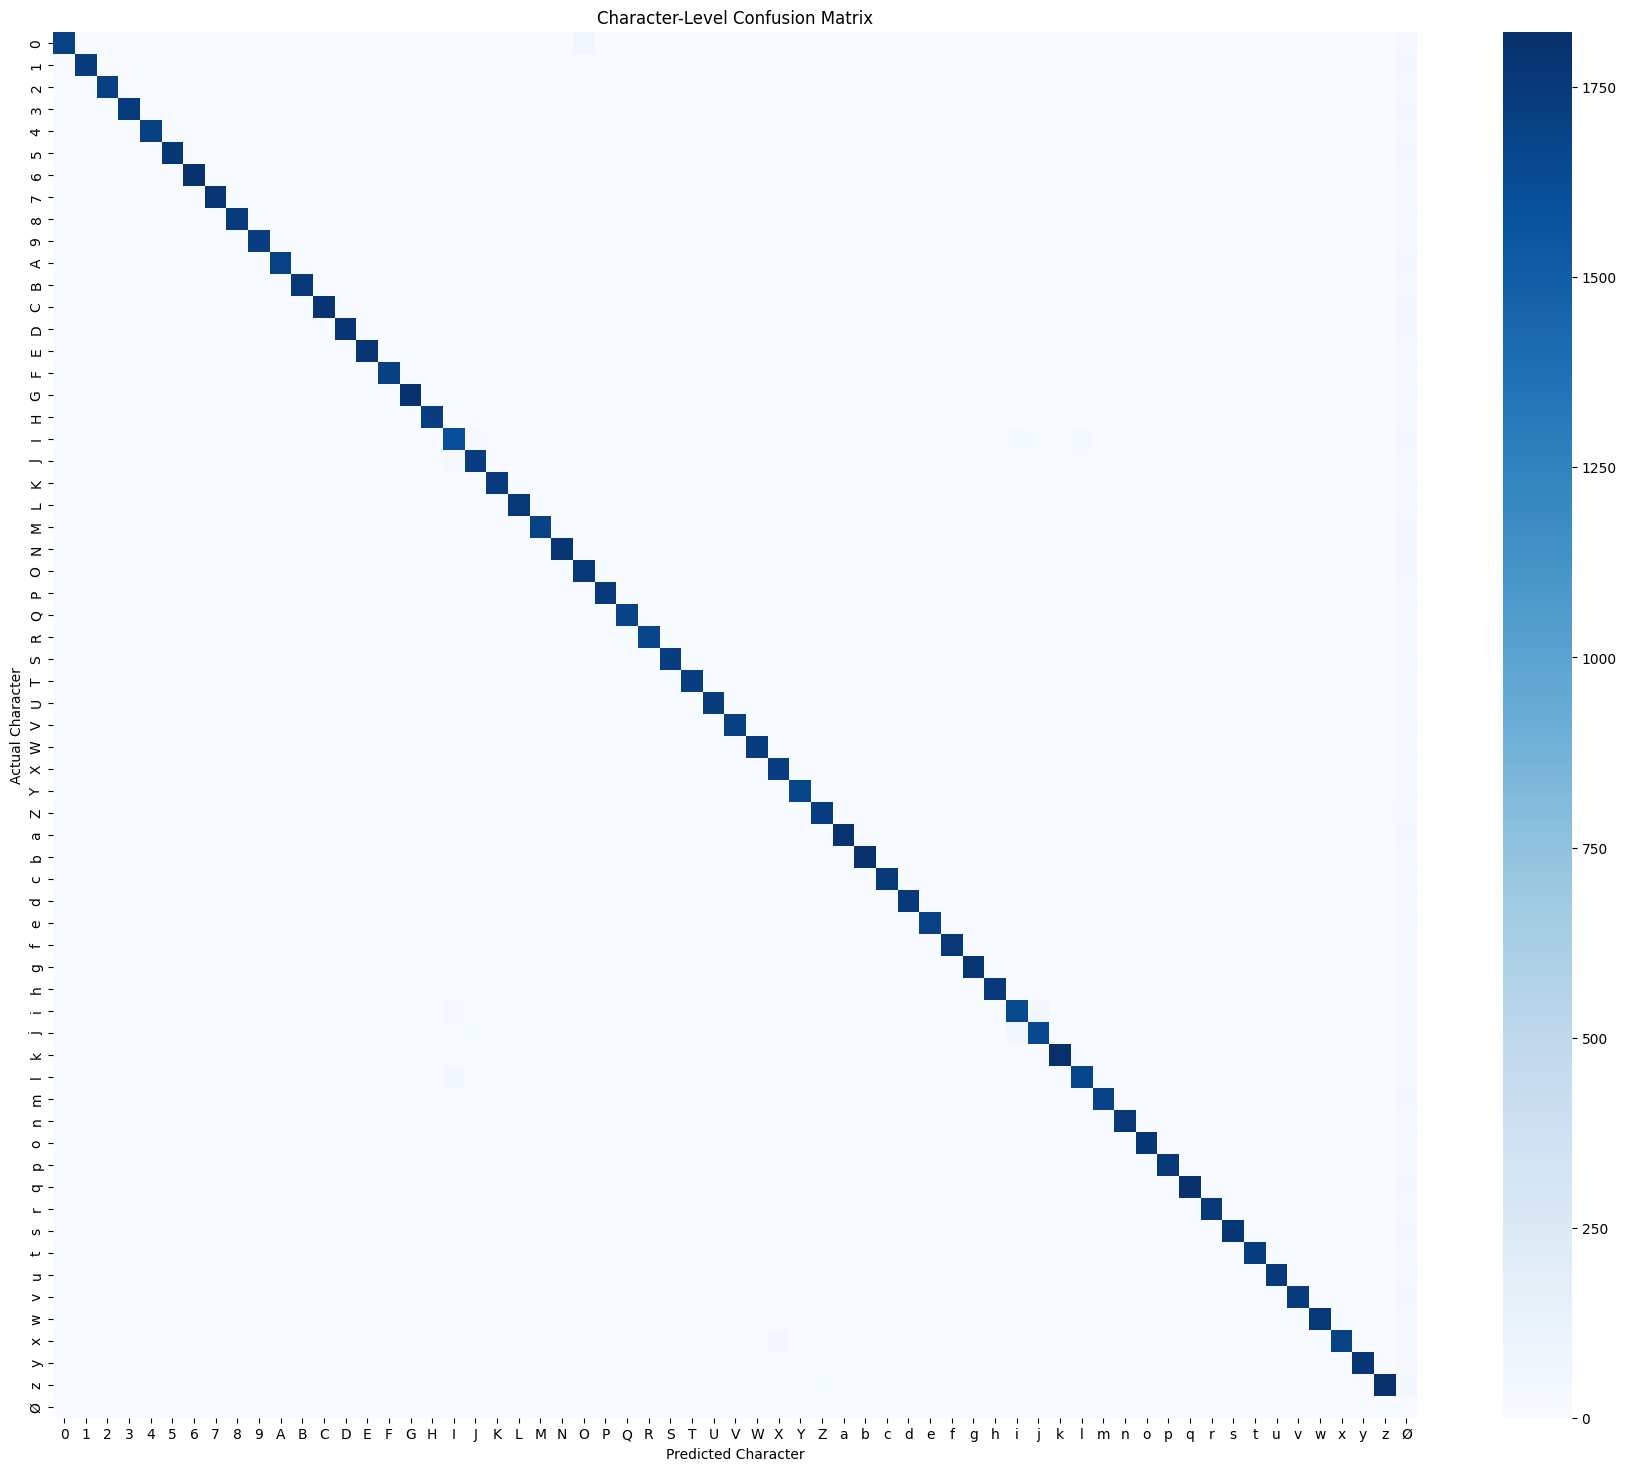

In [13]:
plot_char_confusion_matrix(df_test_results, test_dataset)

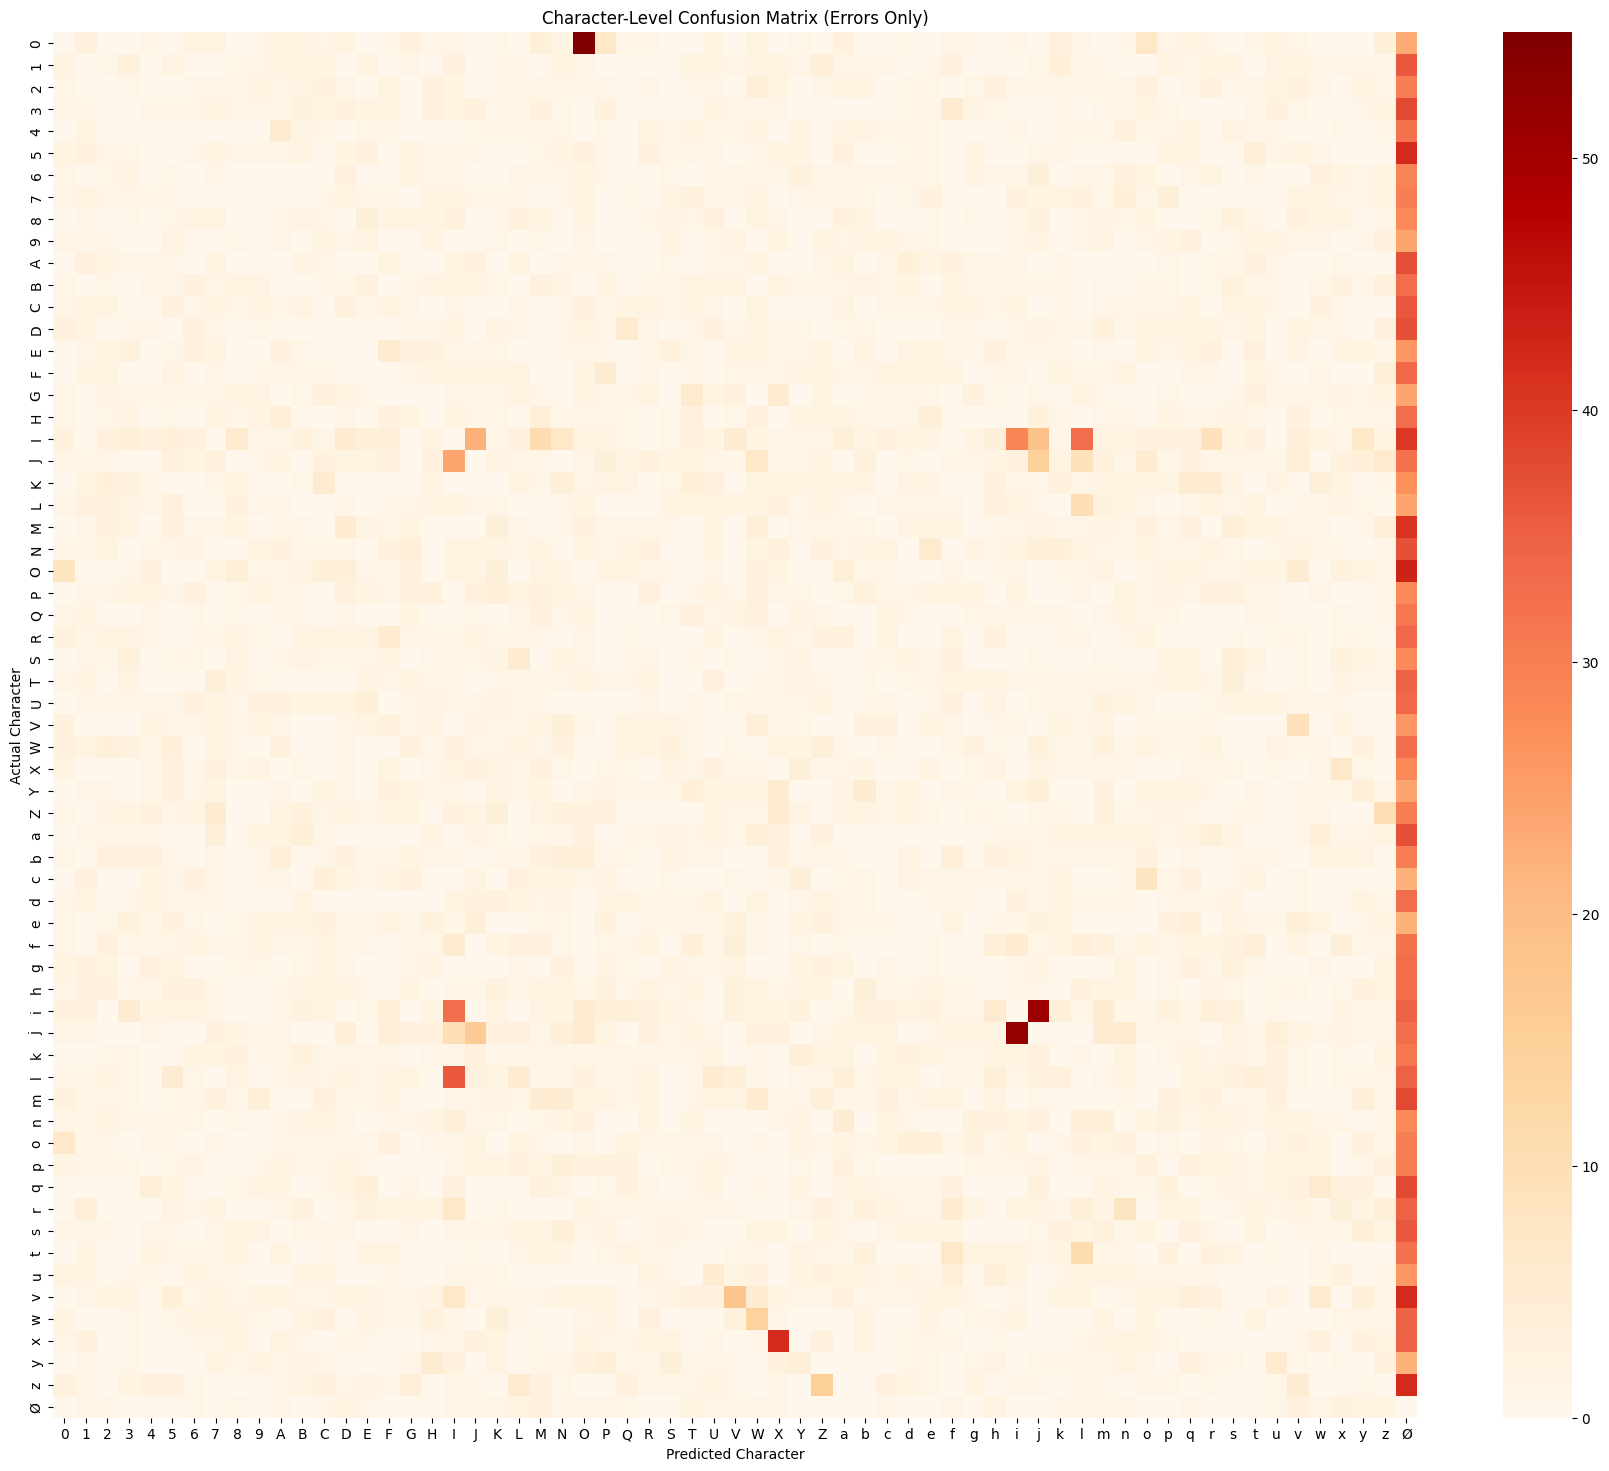

In [14]:
plot_char_confusion_matrix(df_test_results, test_dataset, hide_diagonal=True)

# Visualize Random Predictions

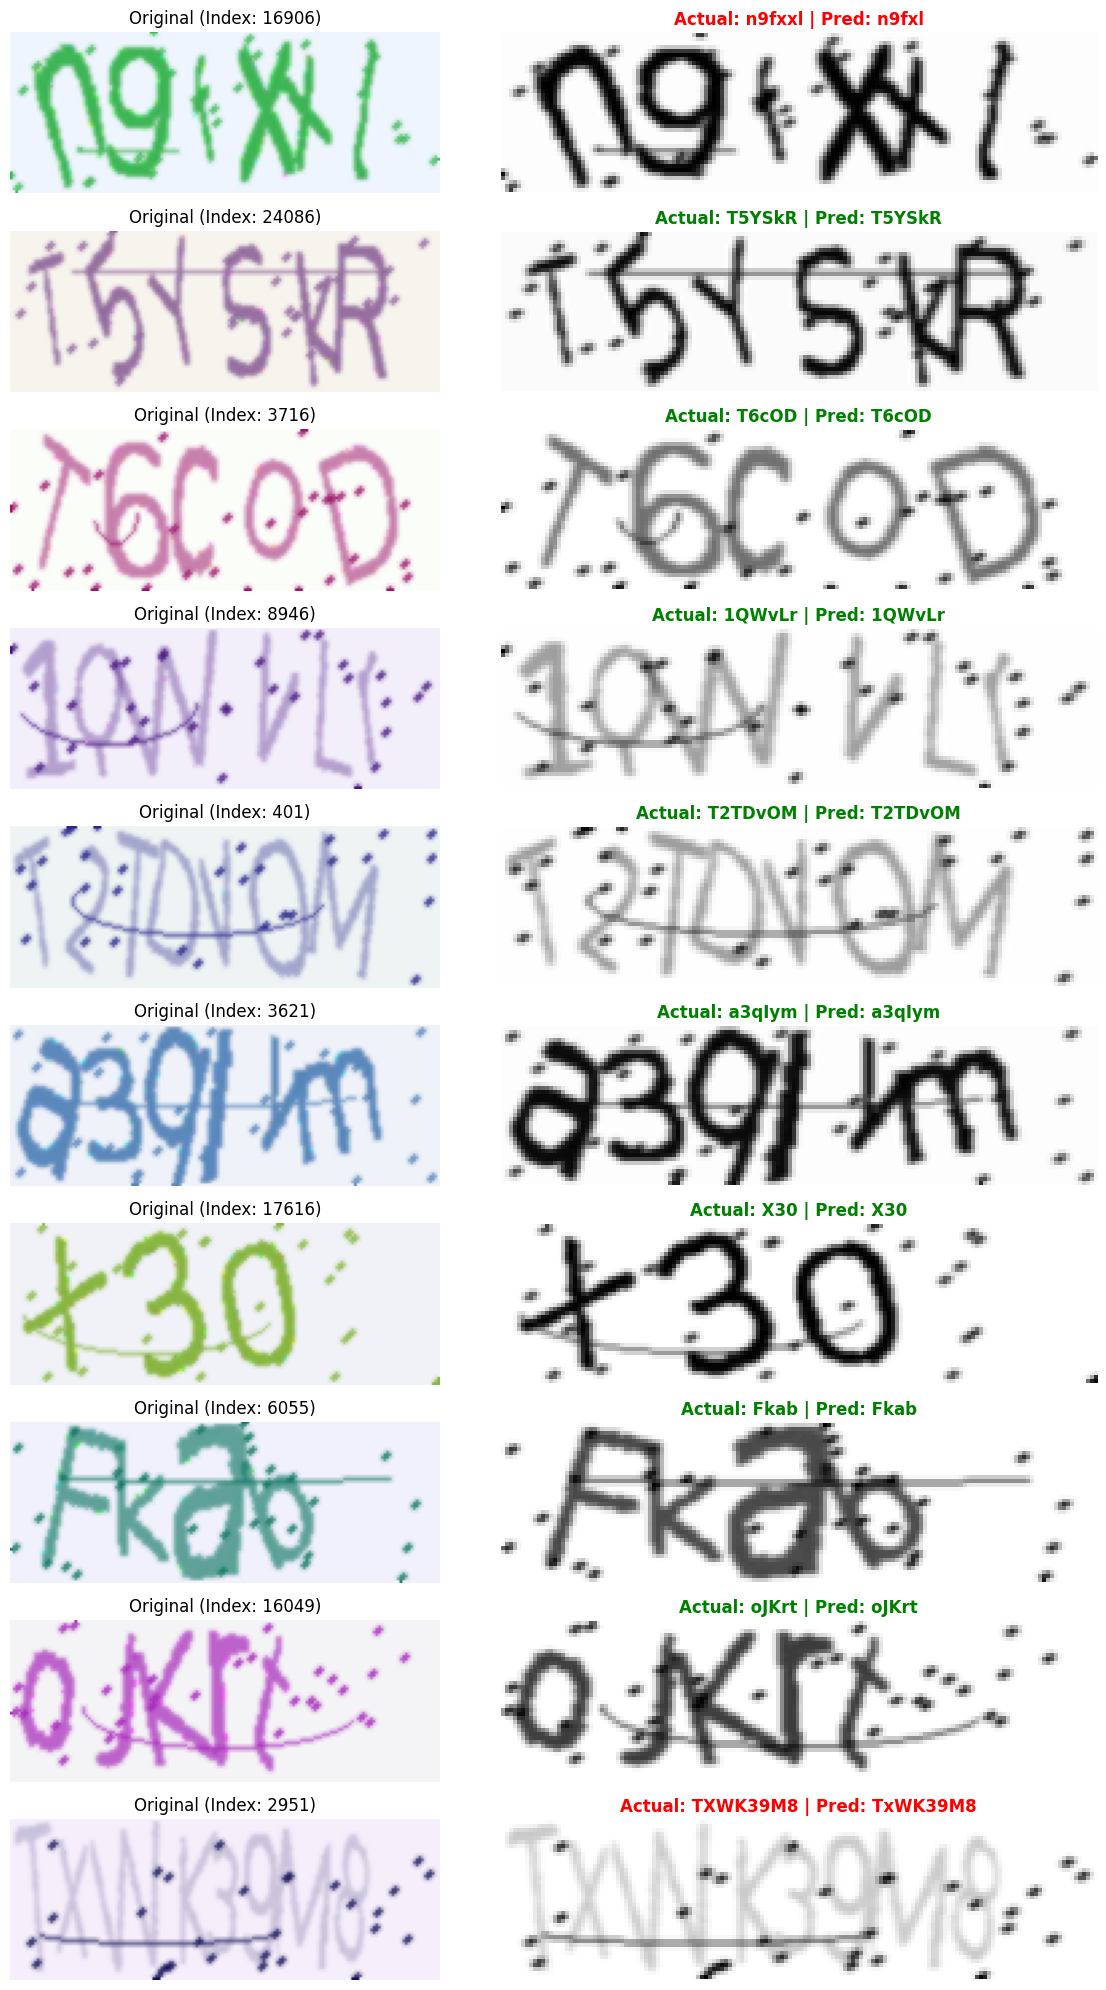

In [15]:
visualize_test_predictions(df_test_results, test_dataset, 10)

# Visualize Random Wrong Predictions

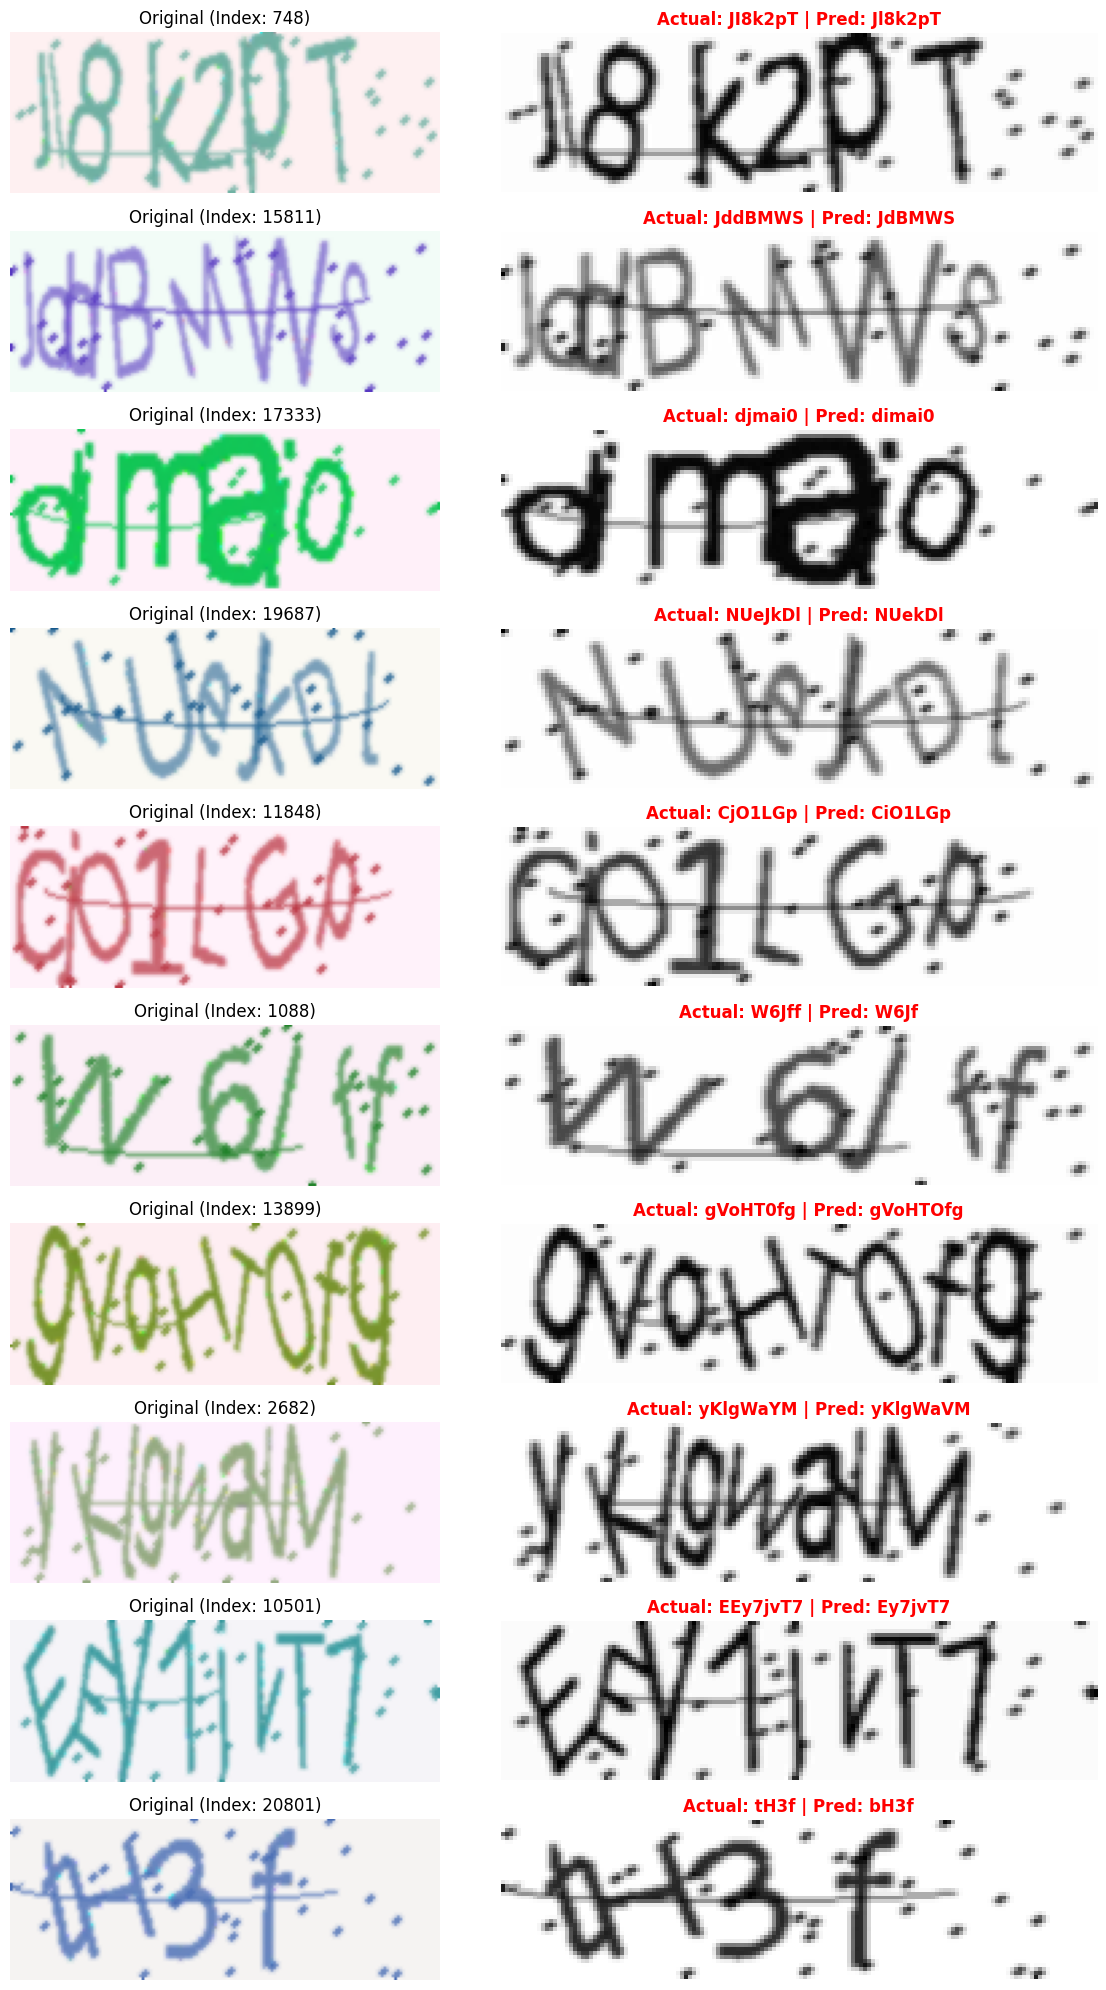

In [16]:
visualize_test_predictions(df_test_results[df_test_results["actual"] != df_test_results["prediction"]], test_dataset, 10)

# Model Stats

In [ ]:
model_stats = summary(model, input_size=(1, 1, 40, 150), verbose=0)
print(f"Total Parameters: {model_stats.total_params:,}")
print(f"Model Size (MB): {model_stats.total_param_bytes / 1e6:.2f} MB")

Total Parameters: 388,800
Model Size (MB): 1.56 MB


# Inference

In [74]:
def benchmark_inference(model, device, input_shape=(1, 1, 40, 150), num_iterations=1000):
    model.eval()
    dummy_input = torch.randn(*input_shape).to(device)
    
    # Warm-up (Standard for GPU benchmarking)
    for _ in range(10):
        _ = model(dummy_input)
    
    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_time = time.time()
    
    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(dummy_input)
            
    torch.cuda.synchronize() if device.type == 'cuda' else None
    end_time = time.time()
    
    total_time = end_time - start_time
    avg_latency = (total_time / num_iterations) * 1000 # in ms
    throughput = num_iterations / total_time # items per second
    
    print(f"Average Latency: {avg_latency:.2f} ms")
    print(f"Throughput: {throughput:.2f} images/sec")

benchmark_inference(model, device)

Average Latency: 12.33 ms
Throughput: 81.11 images/sec


### Generated Test-Data
Metric|CRNN-V4|CRNN-V5|CRNN-V6    |
------|-------|-------|-----------|
Accuracy|9.65%|86.45%|86.20% |
Character-Error-Rate (CER)|43.98%|2.49%|2.53% |
Model Parameters|3,570,943|3,570,943|3,570,943 |
Model Size (MB)|14.28 MB|14.28 MB|14.28 MB |
Images/Second|472.99 (GPU)|467.21 (GPU)|467.21 (GPU) |